In [1]:
%load_ext autoreload
%autoreload 2
import torch
import numpy as np
from tqdm import tqdm
import h5py
import hdf5plugin
import os
from dataclasses import astuple, asdict
from global_variables import *

In [2]:
from deep_bf.config_registery import ConfigRegisteryCenter
from deep_bf.config_registery.path_center import PathCenter

pc = PathCenter(is_server=False)
dataset_paths = pc.get_dataset_paths()

with ConfigRegisteryCenter() as cc:
    mP = cc.get_model_packing(id=1)
    bP = cc.get_beamformer_packing(id=0)
    wC = cc.get_webdataset_config(id=0)

    print(mP)
    print(bP)
    print(wC)

ModelPacking(model_config=ModelConfig(id=1, family='BINN_OG', model_id=3, conv2d_init_id=0, activation_id=0, beamformer_id=0), conv2d_init_config=Conv2dInitConfig(id=0, init_weights='XavierUniform', init_bias='Zeros'), activation_config=ActivationConfig(id=0, type='LeakyReLU', params={'negative_slope': 0.01}), architecture_configs=[ArchitectureCnnBfConfig(model_id=3, family='BINN_OG', pos=0, type='BasicConv2d', ch_in=1, ch_out=16, kernel=(5, 3), padding='same', bias=True), ArchitectureCnnBfConfig(model_id=3, family='BINN_OG', pos=1, type='BasicConv2d', ch_in=16, ch_out=8, kernel=(5, 3), padding='same', bias=True), ArchitectureCnnBfConfig(model_id=3, family='BINN_OG', pos=2, type='BF', ch_in=8, ch_out=8, kernel=(-1, -1), padding='same', bias=True), ArchitectureCnnBfConfig(model_id=3, family='BINN_OG', pos=3, type='BasicConv2d', ch_in=8, ch_out=8, kernel=(5, 3), padding='same', bias=True), ArchitectureCnnBfConfig(model_id=3, family='BINN_OG', pos=4, type='BasicConv2d', ch_in=8, ch_out=4,

In [21]:
from deep_bf.beamformers import get_rf_bmode

bf_names = ["DAS", "MVB"]
nzs = [2048, 1024, 512, 256]
nx = 256

picmus_names = [
    "contrast_speckle_expe_dataset_rf",
    "contrast_speckle_simu_dataset_rf",
    "resolution_distorsion_expe_dataset_rf",
    "resolution_distorsion_simu_dataset_rf",
    "carotid_cross_expe_dataset_rf",
    "carotid_long_expe_dataset_rf"
]

name = picmus_names[5]


pw = DL.get_defined_pwdata(name, "RF")

file_path = dataset_paths.raw / f"{name}.hdf5"

group = "sharifzadeh"
outputs = {}

vmin = -60
vmax = 0

for bf_name in bf_names:
    outputs[bf_name] = {}
    for nz in nzs:
        outputs[bf_name][nz] = {}
    
        with h5py.File(file_path, "r") as f:
            g = f.require_group(f"{group}/{nz}/{bf_name}")

            outputs[bf_name][nz]["central"] = get_rf_bmode(g["ground_truth_central"][:], vmin, vmax)
            outputs[bf_name][nz]["sum"] = get_rf_bmode(g["ground_truth_sum"][:], vmin, vmax)
            outputs[bf_name][nz]["mean"] = get_rf_bmode(g["ground_truth_mean"][:], vmin, vmax)

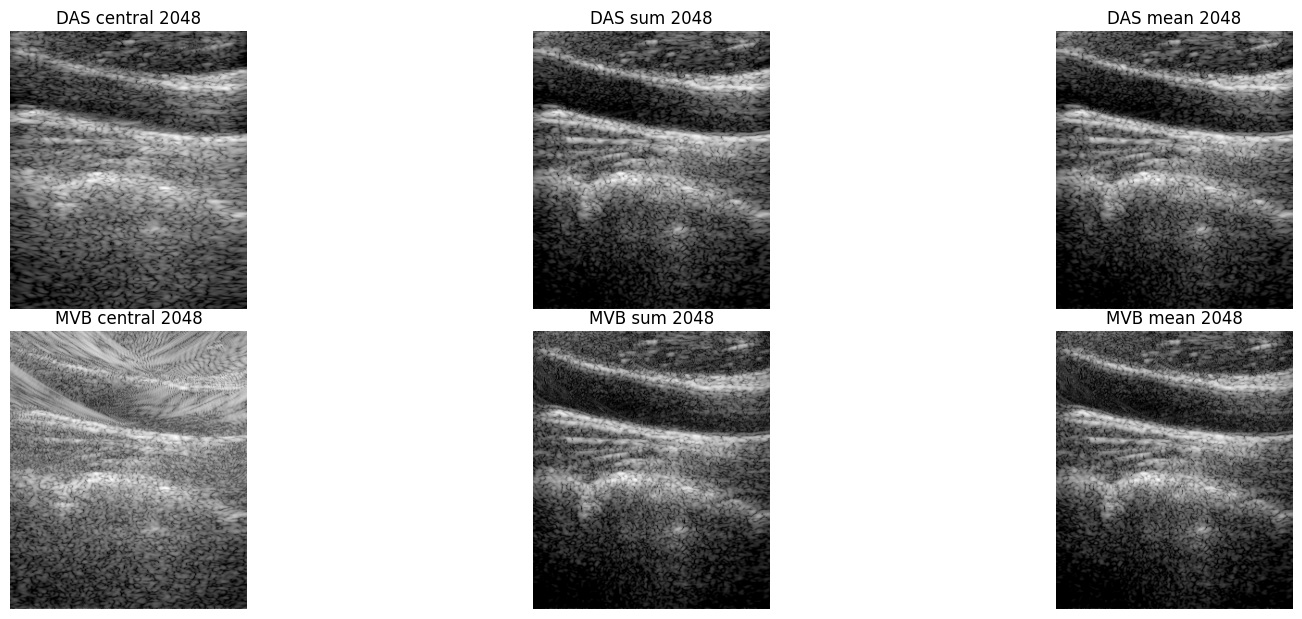

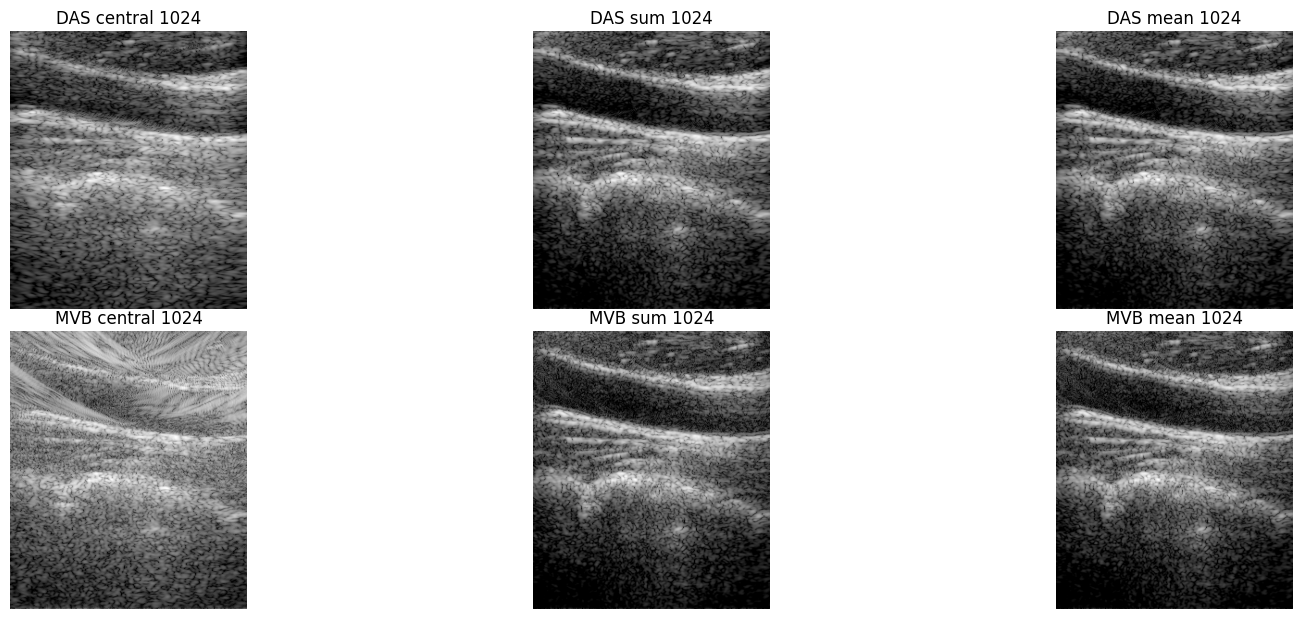

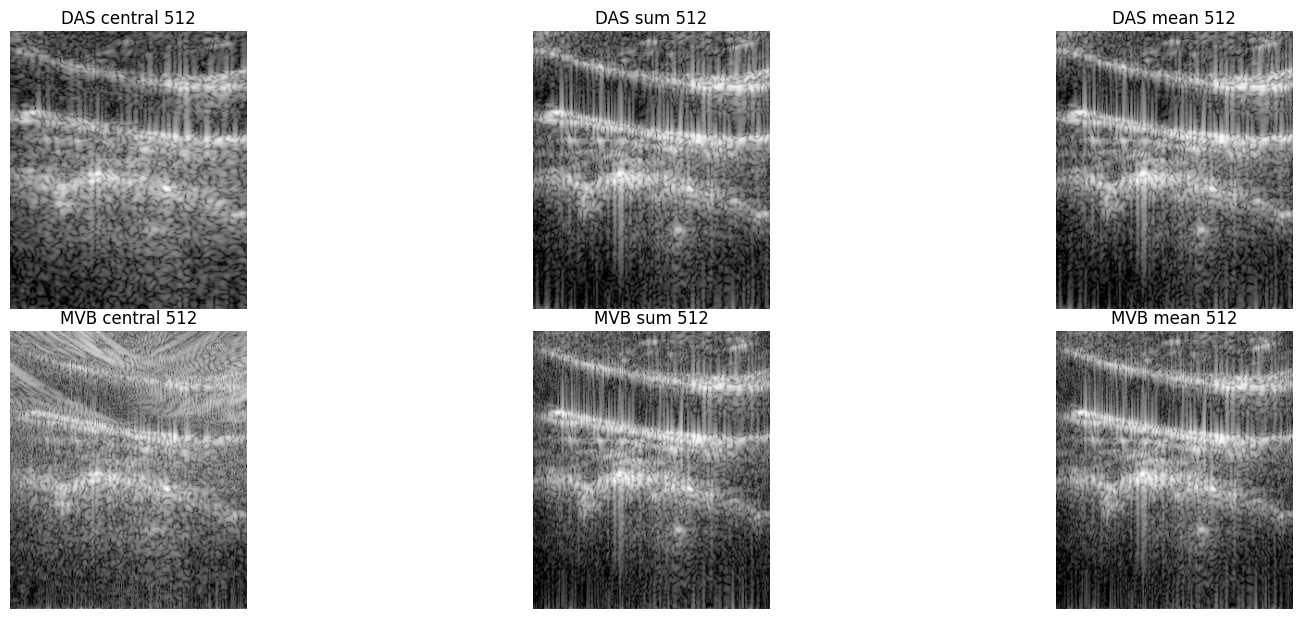

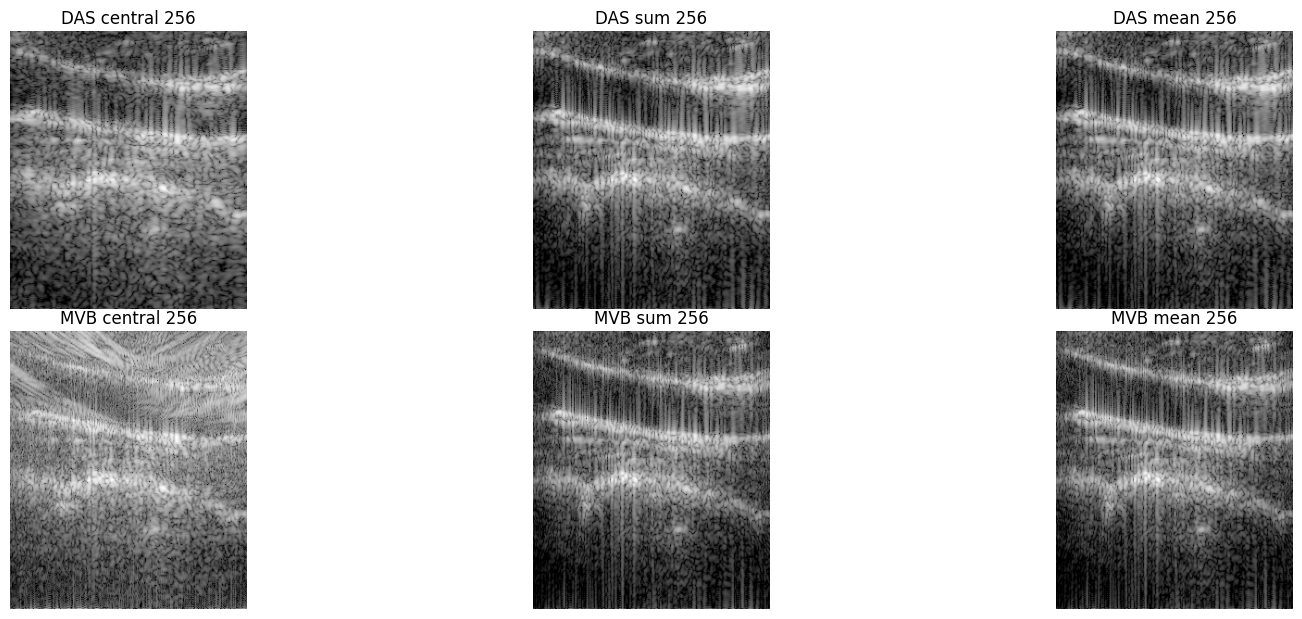

In [22]:
import matplotlib.pyplot as plt
from deep_bf.beamformers import compute_meshgrid, get_rf_bmode

for nz in nzs:
    Z, X = compute_meshgrid(pw, nz, nx)

    Z = Z.cpu()
    X = X.cpu()

    zlims = np.array([Z[0, 0], Z[-1, 0]]) * 1e3
    xlims = np.array([X[0, 0], X[0, -1]]) * 1e3

    vmin = -60
    vmax = 0

    fig, axes = plt.subplots(2, 3, figsize=(18, 6), frameon=False)

    extent = (xlims[0], xlims[-1], zlims[-1], zlims[0])

    for ax, img, title in zip(
        axes.flatten(),
        [
            outputs["DAS"][nz]["central"], outputs["DAS"][nz]["sum"], outputs["DAS"][nz]["mean"], 
            outputs["MVB"][nz]["central"], outputs["MVB"][nz]["sum"], outputs["MVB"][nz]["mean"], 
        ],
        [
            f"DAS central {nz}", f"DAS sum {nz}", f"DAS mean {nz}",
            f"MVB central {nz}", f"MVB sum {nz}", f"MVB mean {nz}",
        ],
    ):
        ax.imshow(img, cmap="gray", vmin=vmin, vmax=vmax, extent=extent, aspect="equal")
        ax.set_title(title)
        ax.set_axis_off()

    plt.tight_layout(pad=0)
    plt.savefig(f"./imgs/{name}_{nz}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
from deep_bf.models.model_builder import model_builder, set_beamformer_layer



toy = set_beamformer_layer()